In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [21]:
#creo funcion img full
def IQM_FF(img_gris):
  m, n = img_gris.shape
  f = np.fft.fft2(img_gris)
  fc = np.fft.fftshift(f)
  af = np.abs(fc)
  max_val = np.max(af)
  thres = max_val / 1000
  th = np.count_nonzero(af > thres)
  fm = th/(m * n)
  return fm


#Creo funcion img roi
def IQM_R(img_gris):
  m, n = img_gris.shape
  #defino el tamaño del ROI
  porcentaje = 0.4
  ancho = int(n * porcentaje)
  alto = int(m * porcentaje)
  #ubico las coordenadas iniciales de mi nueva región
  x = (n // 2) - (ancho // 2)
  y = (m // 2) - (alto // 2)
  #slicing de la matriz para obtener mi nueva región
  roi = img_gris[y : y + alto,
                 x : x + ancho]
  #ahora se aplica el algoritmo
  m_roi, n_roi = roi.shape
  f = np.fft.fft2(roi)
  fc = np.fft.fftshift(f)
  af = np.abs(fc)
  max_val = np.max(af)
  thres = max_val / 1000
  th = np.count_nonzero(af > thres)
  fm_roi = th/(m_roi * n_roi)
  return fm_roi

In [22]:
#Creo listas para guardar los valores de calidad
IQM_fullFrame = []
IQM_ROI= []

In [23]:
# Abre el video
video_path = './focus_video.mov'
captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    print("Procesando video..")
    while captura_video.isOpened():
        ret, frame = captura_video.read()  #ret es un boolean que es True si logró leer el frame correctamente   /  frame:   |matriz de píxeles de la imagen actual
        if not ret:
            break #salgo del bucle cuando me quedo sin frames
    
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        #aca se aplica el algoritmo para analizar la calidad del frame
        f = IQM_FF(frame_gris)
        r = IQM_R(frame_gris)
        #el valor que devuelva agregarlo a la lista para graficar
        IQM_fullFrame.append(f)
        IQM_ROI.append(r)
       

# Libera el objeto de captura de video
captura_video.release()

print("Procesamiento finalizado")

Procesando video..


Procesamiento finalizado


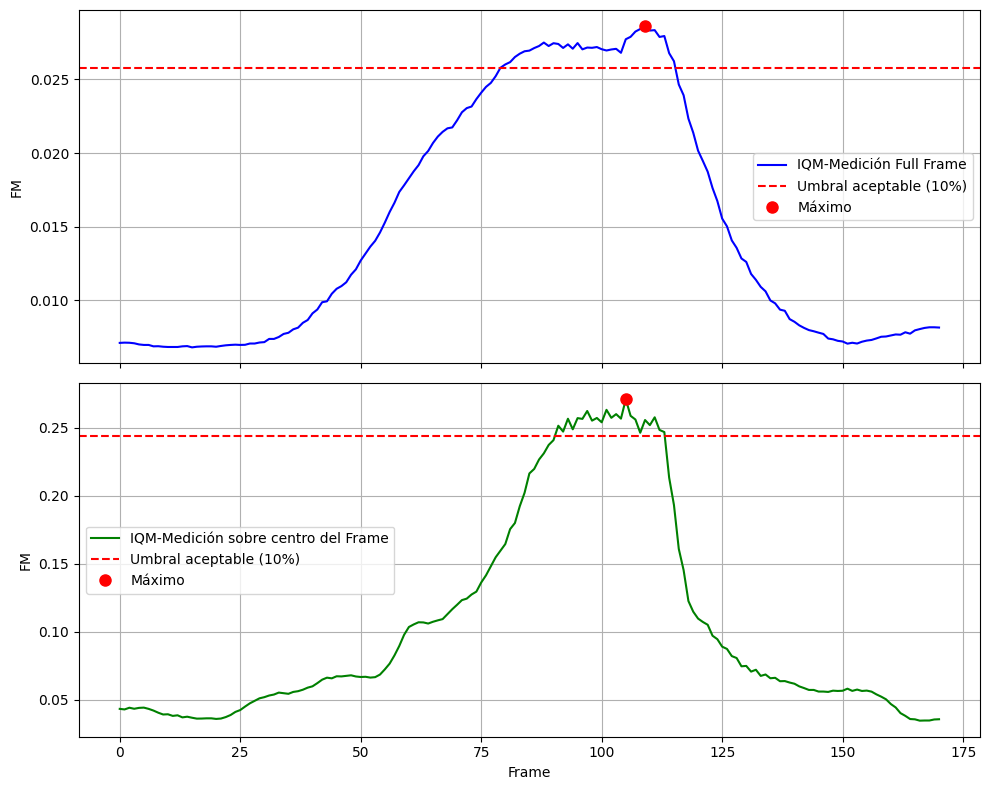

In [24]:
# Gráficos
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(10,8), sharex=True)
#Full Frame
ax1.plot(IQM_fullFrame, color='blue', label='IQM-Medición Full Frame')
max_ff = max(IQM_fullFrame)
idx_max_ff = np.argmax(IQM_fullFrame)
umbral_ff = max_ff * 0.9 # voy a tomar como válidos solo los frames que tengan hasta un valor del 10% por debajo del máximo FM
ax1.axhline(y=umbral_ff, color='red', linestyle='--', label='Umbral aceptable (10%)')
ax1.plot(idx_max_ff, max_ff, 'ro', markersize=8, label='Máximo')

ax1.set_ylabel('FM')
ax1.legend()
ax1.grid(True)

#ROI
ax2.plot(IQM_ROI, color='green', label='IQM-Medición sobre centro del Frame')
max_roi = max(IQM_ROI)
idx_max_roi = np.argmax(IQM_ROI)
umbral_roi = max_roi * 0.9
ax2.axhline(y=umbral_roi, color='red', linestyle='--', label='Umbral aceptable (10%)')
ax2.plot(idx_max_roi, max_roi, 'ro', markersize=8, label='Máximo')

ax2.set_ylabel('FM')
ax2.set_xlabel('Frame')  #eje x global. Comparten el mismo
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#Tomo los frames que superan el umbral de aceptación
region_ff = [i + 1 for i, value in enumerate(IQM_fullFrame) if value >= umbral_ff]
region_roi = [i + 1 for i, value in enumerate(IQM_ROI) if value >= umbral_roi]

In [25]:
#imprimo máximos y regiones de máximo enfoque
print("Resultados")
print(f"Mejor frame (Full FRAME): {np.argmax(IQM_fullFrame) + 1} con valor {max_ff:.4f}")
print(f"Región de máximo enfoque(Full FRAME): Frames {region_ff}")
print(f"Mejor frame (ROI): {np.argmax(IQM_ROI) + 1} con valor {max_roi:.4f}")
print(f"Región de máximo enfoque(ROI): Frames {region_roi}")


Resultados
Mejor frame (Full FRAME): 110 con valor 0.0286
Región de máximo enfoque(Full FRAME): Frames [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116]
Mejor frame (ROI): 106 con valor 0.2707
Región de máximo enfoque(ROI): Frames [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]


Hago una prueba visual de la calidad de los frames que estan en los limites de la region vs el de mayor calidad

Para el experimento sobre Full Frames:

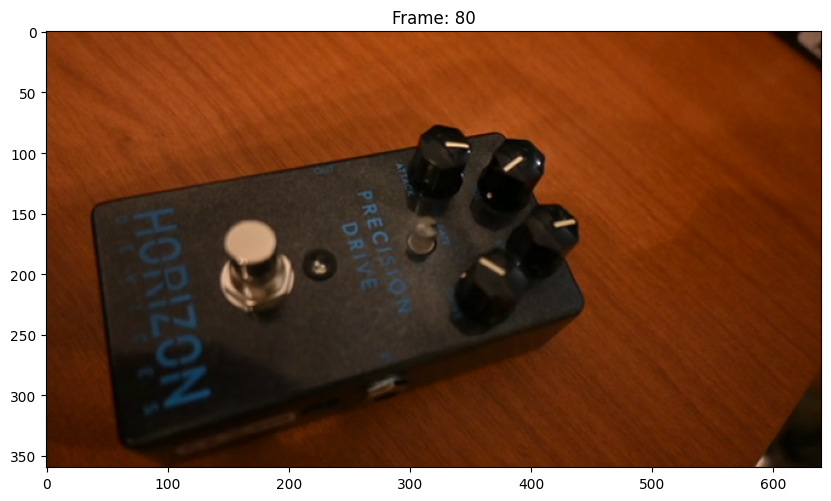

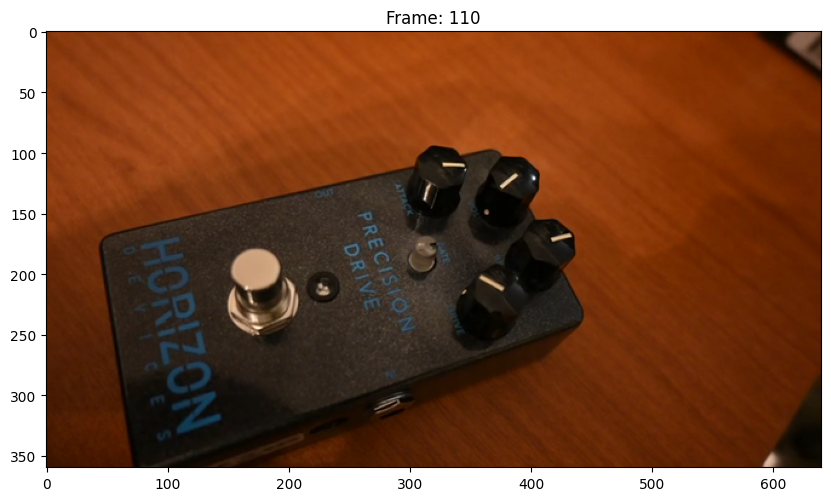

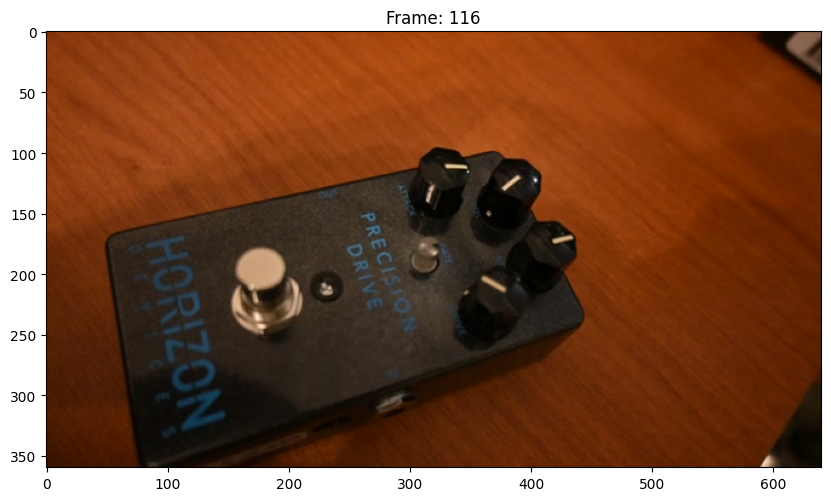

In [19]:
#Leo el video nuevamente, pero salto derecho a los frames que me interesan
frms_ff = [region_ff[0], idx_max_ff + 1, region_ff[-1]]
video_path = './focus_video.mov'
cap = cv2.VideoCapture(video_path)

for f in frms_ff:
    cap.set(cv2.CAP_PROP_POS_FRAMES, f - 1)
    ret, frame = cap.read()

    if ret:
        plt.figure(figsize=(10,6))
        frm_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frm_rgb)
        plt.title(f"Frame: {f}")
cap.release
cv2.destroyAllWindows()

Para el experimento sobre ROI:

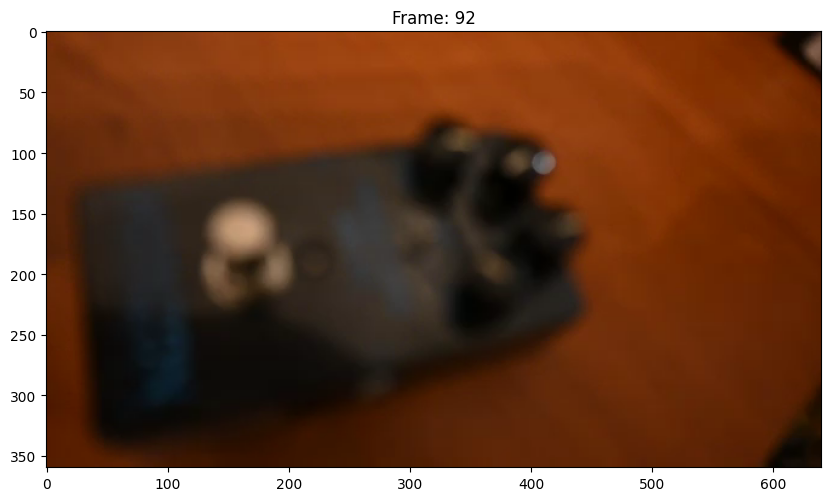

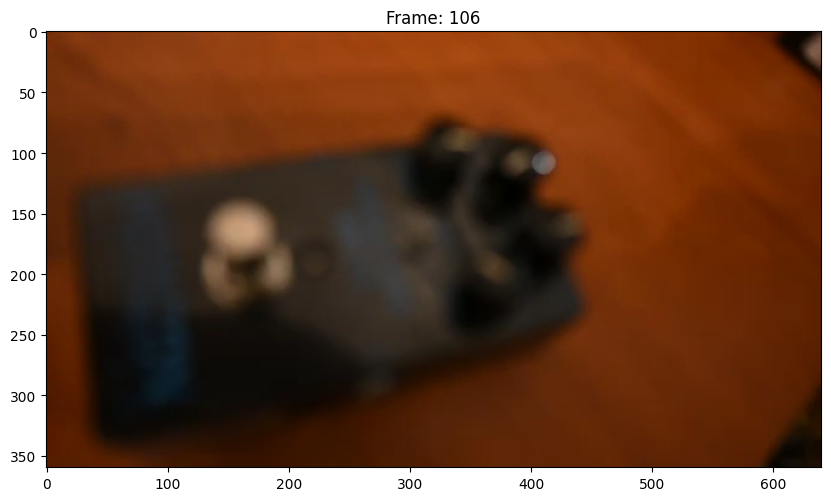

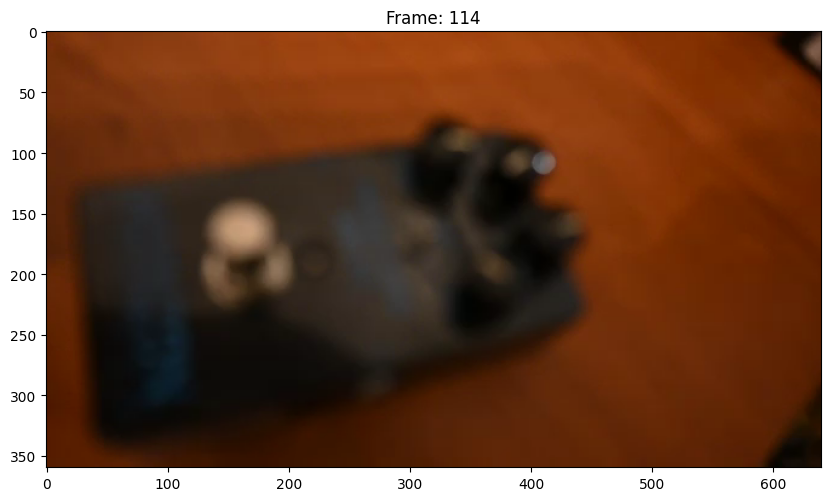

In [26]:
#Leo el video nuevamente, pero salto derecho a los frames que me interesan
frms_roi = [region_roi[0], idx_max_roi + 1, region_roi[-1]]
video_path = './focus_video.mov'
cap = cv2.VideoCapture(video_path)

for fr in frms_roi:
    cap.set(cv2.CAP_PROP_POS_FRAMES, f - 1)
    ret, frame = cap.read()

    if ret:
        plt.figure(figsize=(10,6))
        frm_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frm_rgb)
        plt.title(f"Frame: {fr}")
cap.release
cv2.destroyAllWindows()